# MoRobtrol HV / EU Evaluation

Load NSGA-III and RVEA snapshots, build their pooled empirical nondominated reward front, compute HV/EU, and visualize the comparison.

In [1]:
from pathlib import Path
import sys
import torch

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "CMakeLists.txt").exists():
        repo_root = candidate
        break
evaluation_dir = repo_root / "tests" / "evaluation"
sys.path.insert(0, str(evaluation_dir))

from metrics import expected_utility, hypervolume, nondominated_mask
from snapshot_io import default_torch_device, feasible_objectives, load_metadata
from visualization import plot_front_comparison

## Configuration

In [2]:
run_root = repo_root / "output" / "morobtrol" / "mo_swimmer"
runs = {
    "NSGA-III": run_root / "nsga3", 
    "RVEA": run_root / "rvea"
}
generation = "latest"
device = default_torch_device()
hv_method = "auto"
hv_samples = 16384
utility_samples = 4096
seed = 2887

## Empirical front, HV, and EU

In [3]:
problem_name = load_metadata(next(iter(runs.values()))).get("problem_name", run_root.name)
rewards = {name: -feasible_objectives(path, generation).to(device) for name, path in runs.items()}
fronts = {name: values[nondominated_mask(-values)] for name, values in rewards.items()}
combined = torch.cat(tuple(rewards.values()), dim=0)
empirical_front = combined[nondominated_mask(-combined)]

ideal = empirical_front.amax(dim=0)
nadir = empirical_front.amin(dim=0)
span = (ideal - nadir).clamp_min(torch.finfo(empirical_front.dtype).eps)
utility_nadir = ideal - span
hv_reference = nadir - 0.1 * span

scores = {}
for name, front in fronts.items():
    scores[name] = {
        "HV": hypervolume(front, hv_reference, maximize=True, method=hv_method, samples=hv_samples, seed=seed, device=device),
        "EU": expected_utility(front, maximize=True, ideal_point=ideal, nadir_point=utility_nadir, weight_samples=utility_samples, seed=seed, device=device),
        "nondominated_points": front.shape[0],
    }
scores

{'NSGA-III': {'HV': 38.714988708496094,
  'EU': 0.7535959482192993,
  'nondominated_points': 43},
 'RVEA': {'HV': 38.03017807006836,
  'EU': 0.6766113042831421,
  'nondominated_points': 35}}

## Final nondominated fronts visualization

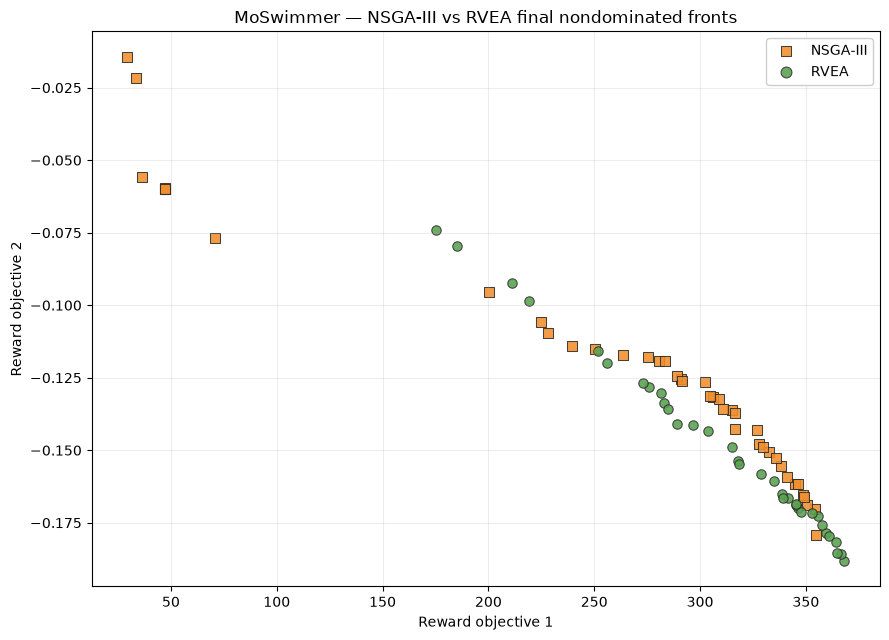

In [4]:
plot_front_comparison(
    fronts,
    None,
    output_path=run_root / "evaluation" / "final_fronts.png",
    title=f"{problem_name} — {' vs '.join(fronts)} final nondominated fronts",
)